In [12]:
import io
import matplotlib.pyplot as plt
import ssl
import urllib.request
# Cell 1 — Imports & basic setup
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Import data

In [13]:
station_url = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/wae/ogd-smn_wae_d_historical.csv"

ctx = ssl.create_default_context()

raw_text = urllib.request.urlopen(station_url, context=ctx).read().decode("utf-8")

try:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=None, engine="python")
except Exception:
    station_df = pd.read_csv(io.StringIO(raw_text), sep=";")

station_df.head()


,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,WAE,01.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WAE,02.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WAE,03.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WAE,04.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WAE,05.01.1961 00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
rename_dict = {
    "tre200d0": "temp2m_mean_d",
    "tre200dx": "temp2m_max_d",
    "tre200dn": "temp2m_min_d",
    "tre005d0": "temp5cm_mean_d",
    "tre005dx": "temp5cm_max_d",
    "tre005dn": "temp5cm_min_d",
    "ure200d0": "rh2m_mean_d",
    "pva200d0": "vapor_pressure_d",
    "fkl010d0": "wind_ms_mean_d",
    "fkl010d1": "gust_ms_max_d",
    "fu3010d0": "wind_kmh_mean_d",
    "fu3010d1": "gust_kmh_max_d",
    "rka150d0": "precip_0utc_d",
    "dkl010d0": "wind_dir_mean_d",
    "xno000d0": "heating_degree_days_d",
    "xno012d0": "heating_degree_days_atd12_d",
    "rreetsd0": "water_balance_d",
    "tso005d0": "soil_temp_5cm_mean_d",
    "tso010d0": "soil_temp_10cm_mean_d",
    "tso020d0": "soil_temp_20cm_mean_d",
}

base_cols = ["station_abbr", "reference_timestamp"]
value_cols = [c for c in rename_dict if c in station_df.columns]

df = station_df[base_cols + value_cols].copy()
df["reference_timestamp"] = pd.to_datetime(df["reference_timestamp"], dayfirst=True, errors="coerce")
df = df.rename(columns=rename_dict)

df = df.dropna().reset_index(drop=True)
df.head()

,station_abbr,reference_timestamp,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,vapor_pressure_d,...,wind_kmh_mean_d,gust_kmh_max_d,precip_0utc_d,wind_dir_mean_d,heating_degree_days_d,heating_degree_days_atd12_d,water_balance_d,soil_temp_5cm_mean_d,soil_temp_10cm_mean_d,soil_temp_20cm_mean_d
0,WAE,1981-01-01,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,4.9,...,17.6,50.4,1.2,259.0,17.3,9.3,1.1,0.2,0.5,1.0
1,WAE,1981-01-02,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,5.5,...,11.9,47.9,4.4,252.0,18.5,10.5,4.3,0.2,0.6,1.0
2,WAE,1981-01-03,6.2,9.3,2.4,4.9,8.3,0.3,62.8,5.9,...,21.6,81.4,11.2,261.0,13.8,5.8,11.1,1.0,0.9,1.1
3,WAE,1981-01-04,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,6.3,...,14.0,77.0,26.4,260.0,17.4,9.4,26.4,1.8,1.8,1.8
4,WAE,1981-01-05,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,4.3,...,24.1,60.5,2.0,250.0,20.5,12.5,1.9,1.0,1.2,1.5


In [15]:
TARGET_COL = "precip_0utc_d"

# Column that identifies the station (CHANGE to your actual column name!)
STATION_COL = "station_abbr" 

# If you have a date/time column (CHANGE to your actual column name or keep None)
DATE_COL = "reference_timestamp"  # e.g. "time", "datetime", "timestamp", or None

# Splits
TEST_SIZE = 0.2
VAL_SIZE  = 0.2
RANDOM_SEED = 42

# If DATE_COL is not None, we do a time-aware split (recommended for time series)
TIME_AWARE_SPLIT = True if DATE_COL else False

In [16]:
# Cell 4 — Build candidate features automatically + time encoding

def add_time_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """
    Adds useful numeric time features.
    Keeps the original date column (you can drop it later).
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    # day-of-year cyclic encoding
    doy = d[date_col].dt.dayofyear.astype(int)
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    # optional extras (comment out if you want)
    d["year"] = d[date_col].dt.year.astype(int)
    d["month"] = d[date_col].dt.month.astype(int)

    return d

# Add time features if date column exists
if DATE_COL is not None:
    df = add_time_features(df, DATE_COL)

# Candidate features = all columns except target + station (+ raw date column if present)
excluded = {TARGET_COL, STATION_COL}
if DATE_COL is not None:
    excluded.add(DATE_COL)  # exclude raw datetime; we use the encoded features instead

CANDIDATE_FEATURES = [c for c in df.columns if c not in excluded]

# Keep only numeric candidate features (important!)
numeric_candidates = []
for c in CANDIDATE_FEATURES:
    if pd.api.types.is_numeric_dtype(df[c]):
        numeric_candidates.append(c)

CANDIDATE_FEATURES = numeric_candidates

print("Target:", TARGET_COL)
print("Excluded:", excluded)
print("Num candidate features:", len(CANDIDATE_FEATURES))
print("First candidates:", CANDIDATE_FEATURES[:15])

Target: precip_0utc_d
Excluded: {'station_abbr', 'reference_timestamp', 'precip_0utc_d'}
Num candidate features: 23
First candidates: ['temp2m_mean_d', 'temp2m_max_d', 'temp2m_min_d', 'temp5cm_mean_d', 'temp5cm_max_d', 'temp5cm_min_d', 'rh2m_mean_d', 'vapor_pressure_d', 'wind_ms_mean_d', 'gust_ms_max_d', 'wind_kmh_mean_d', 'gust_kmh_max_d', 'wind_dir_mean_d', 'heating_degree_days_d', 'heating_degree_days_atd12_d']


In [17]:
# Cell 5 — Sanity checks (UPDATED)

missing = [c for c in [TARGET_COL, STATION_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

if DATE_COL is not None and DATE_COL not in df.columns:
    raise ValueError(f"DATE_COL='{DATE_COL}' not found in df. Set DATE_COL=None or correct the name.")

if len(CANDIDATE_FEATURES) == 0:
    raise ValueError("No numeric candidate features found after exclusions.")

df[[TARGET_COL] + CANDIDATE_FEATURES[:10]].head()

,precip_0utc_d,temp2m_mean_d,temp2m_max_d,temp2m_min_d,temp5cm_mean_d,temp5cm_max_d,temp5cm_min_d,rh2m_mean_d,vapor_pressure_d,wind_ms_mean_d,gust_ms_max_d
0,1.2,2.7,5.2,-3.2,1.4,4.6,-6.0,66.4,4.9,4.9,14.0
1,4.4,1.5,3.5,0.2,1.0,2.8,-0.2,80.5,5.5,3.3,13.3
2,11.2,6.2,9.3,2.4,4.9,8.3,0.3,62.8,5.9,6.0,22.6
3,26.4,2.6,6.2,-2.2,1.8,4.9,-2.0,84.1,6.3,3.9,21.4
4,2.0,-0.5,1.3,-1.8,-0.8,1.8,-2.3,73.2,4.3,6.7,16.8


In [18]:
# Cell 6 — (Optional) Add precipitation lag features (still recommended)
# This assumes rows are ordered by time per station; if you have multiple stations,
# we create lags within each station.

LAGS = [1, 2, 3]  # set [] to disable

if LAGS:
    if DATE_COL is not None:
        df = df.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

    for L in LAGS:
        lag_name = f"precip_lag{L}"
        df[lag_name] = df.groupby(STATION_COL)[TARGET_COL].shift(L)

    for L in LAGS:
        lag_name = f"precip_lag{L}"
        if lag_name not in CANDIDATE_FEATURES:
            CANDIDATE_FEATURES.append(lag_name)

print("Num candidate features (after lags):", len(CANDIDATE_FEATURES))

Num candidate features (after lags): 26


In [19]:
# Cell 7 — Data preparation (UPDATED to respect time-aware split)
# Replace your previous make_splits cell with this one.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def make_splits(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
    station_col: str,
    test_size: float = 0.2,
    val_size: float = 0.2,
    random_seed: int = 42,
    date_col: Optional[str] = None,
    time_aware_split: bool = False
):
    d = df.copy()

    # drop missing values in used cols
    used_cols = feature_cols + [target_col, station_col] + ([date_col] if date_col else [])
    d = d.dropna(subset=[c for c in used_cols if c is not None]).reset_index(drop=True)

    if time_aware_split and date_col is not None:
        d[date_col] = pd.to_datetime(d[date_col])
        d = d.sort_values([station_col, date_col]).reset_index(drop=True)

        # Time split globally (keeps chronology). If you prefer per-station split, say so.
        n = len(d)
        n_test = int(np.floor(test_size * n))
        n_trainval = n - n_test
        n_val = int(np.floor(val_size * n_trainval))
        n_train = n_trainval - n_val

        train_df = d.iloc[:n_train]
        val_df   = d.iloc[n_train:n_train+n_val]
        test_df  = d.iloc[n_train+n_val:]
    else:
        trainval_df, test_df = train_test_split(d, test_size=test_size, random_state=random_seed)
        train_df, val_df = train_test_split(trainval_df, test_size=val_size, random_state=random_seed)

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df[target_col].to_numpy(dtype=float)

    X_val = val_df[feature_cols].to_numpy(dtype=float)
    y_val = val_df[target_col].to_numpy(dtype=float)

    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df[target_col].to_numpy(dtype=float)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    return (X_train_s, y_train), (X_val_s, y_val), (X_test_s, y_test), scaler

(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = make_splits(
    df=df,
    target_col=TARGET_COL,
    feature_cols=CANDIDATE_FEATURES,
    station_col=STATION_COL,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_seed=RANDOM_SEED,
    date_col=DATE_COL,
    time_aware_split=TIME_AWARE_SPLIT
)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Shapes: (9888, 26) (2471, 26) (3089, 26)


In [20]:
# Cell 6 — Objective helpers (linear model + MSE / RMSE)

def add_bias(X: np.ndarray) -> np.ndarray:
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mse_loss(Xb: np.ndarray, y: np.ndarray, w: np.ndarray, l2: float = 0.0) -> float:
    preds = Xb @ w
    mse = np.mean((preds - y) ** 2)
    if l2 > 0:
        mse += l2 * np.sum(w[1:] ** 2)  # do not regularize bias
    return float(mse)

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [21]:
# Cell 7 — Gradient Descent (GD)

@dataclass
class GDConfig:
    lr: float = 0.05
    steps: int = 2000
    l2: float = 0.0
    tol: float = 1e-9

def fit_gd(X: np.ndarray, y: np.ndarray, cfg: GDConfig) -> Tuple[np.ndarray, List[float]]:
    Xb = add_bias(X)
    n, d = Xb.shape
    w = np.zeros(d, dtype=float)

    history = []
    prev = np.inf

    for _ in range(cfg.steps):
        preds = Xb @ w
        err = preds - y
        grad = (2.0 / n) * (Xb.T @ err)

        if cfg.l2 > 0:
            reg = np.zeros_like(w)
            reg[1:] = 2 * cfg.l2 * w[1:]
            grad += reg

        w -= cfg.lr * grad

        loss = np.mean(err ** 2) + (cfg.l2 * np.sum(w[1:] ** 2) if cfg.l2 > 0 else 0.0)
        history.append(float(loss))

        if abs(prev - loss) < cfg.tol:
            break
        prev = loss

    return w, history

In [22]:
# Cell 8 — Simulated Annealing (SA) for continuous weights

@dataclass
class SAConfig:
    steps: int = 4000
    T0: float = 1.0
    alpha: float = 0.995
    step_sigma: float = 0.05
    l2: float = 0.0
    seed: int = 42

def fit_sa(X: np.ndarray, y: np.ndarray, cfg: SAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    w = rng.normal(0, 0.1, size=d)
    best_w = w.copy()

    cur = mse_loss(Xb, y, w, l2=cfg.l2)
    best = cur

    T = cfg.T0
    history = [cur]

    for _ in range(cfg.steps):
        w_new = w + rng.normal(0, cfg.step_sigma, size=d)
        new = mse_loss(Xb, y, w_new, l2=cfg.l2)

        delta = new - cur
        if delta <= 0 or rng.random() < np.exp(-delta / max(T, 1e-12)):
            w = w_new
            cur = new
            if cur < best:
                best = cur
                best_w = w.copy()

        history.append(cur)
        T *= cfg.alpha

    return best_w, history

In [23]:
# Cell 9 — Genetic Algorithm (GA) for continuous weights (real-coded)

@dataclass
class GAConfig:
    pop_size: int = 60
    generations: int = 120
    elite: int = 4
    tournament_k: int = 3
    crossover_rate: float = 0.9
    mutation_rate: float = 0.2
    mutation_sigma: float = 0.05
    init_sigma: float = 0.3
    l2: float = 0.0
    seed: int = 42

def tournament_select(rng, fitness: np.ndarray, k: int) -> int:
    idx = rng.integers(0, len(fitness), size=k)
    return idx[np.argmax(fitness[idx])]

def blend_crossover(rng, a: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    alpha = rng.random()
    c1 = alpha * a + (1 - alpha) * b
    c2 = (1 - alpha) * a + alpha * b
    return c1, c2

def fit_ga(X: np.ndarray, y: np.ndarray, cfg: GAConfig) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(cfg.seed)
    Xb = add_bias(X)
    d = Xb.shape[1]

    pop = rng.normal(0, cfg.init_sigma, size=(cfg.pop_size, d))

    def fitness_of(w: np.ndarray) -> float:
        return -mse_loss(Xb, y, w, l2=cfg.l2)

    history = []
    best_w = None
    best_loss = np.inf

    for _ in range(cfg.generations):
        fit = np.array([fitness_of(ind) for ind in pop], dtype=float)
        losses = -fit

        gbest_idx = int(np.argmin(losses))
        if float(losses[gbest_idx]) < best_loss:
            best_loss = float(losses[gbest_idx])
            best_w = pop[gbest_idx].copy()

        history.append(best_loss)

        elite_idx = np.argsort(losses)[:cfg.elite]
        new_pop = [pop[i].copy() for i in elite_idx]

        while len(new_pop) < cfg.pop_size:
            p1 = pop[tournament_select(rng, fit, cfg.tournament_k)]
            p2 = pop[tournament_select(rng, fit, cfg.tournament_k)]

            c1, c2 = p1.copy(), p2.copy()
            if rng.random() < cfg.crossover_rate:
                c1, c2 = blend_crossover(rng, p1, p2)

            if rng.random() < cfg.mutation_rate:
                c1 += rng.normal(0, cfg.mutation_sigma, size=d)
            if rng.random() < cfg.mutation_rate:
                c2 += rng.normal(0, cfg.mutation_sigma, size=d)

            new_pop.append(c1)
            if len(new_pop) < cfg.pop_size:
                new_pop.append(c2)

        pop = np.vstack(new_pop)

    return best_w, history

In [24]:
# Cell 10 — Ant Colony Optimization (ACO) for FEATURE selection (uses GD as cheap evaluator)

@dataclass
class ACOConfig:
    n_ants: int = 50
    n_iters: int = 30
    evaporation: float = 0.2   # rho
    q: float = 1.0             # deposit scaling
    top_k: int = 10            # reinforce from best k ants
    subset_min: int = 2
    subset_max: int = 10
    seed: int = 42

def sample_subset(rng, pheromone: np.ndarray, subset_size: int) -> np.ndarray:
    p = pheromone / pheromone.sum()
    return rng.choice(len(pheromone), size=subset_size, replace=False, p=p)

def evaluate_subset_with_gd(
    X_train_full: np.ndarray, y_train: np.ndarray,
    X_val_full: np.ndarray, y_val: np.ndarray,
    idx: np.ndarray,
    gd_cfg: GDConfig
) -> float:
    Xtr = X_train_full[:, idx]
    Xva = X_val_full[:, idx]
    w, _ = fit_gd(Xtr, y_train, gd_cfg)
    preds = add_bias(Xva) @ w
    return float(mean_squared_error(y_val, preds))

def aco_feature_selection(
    X_train_full: np.ndarray, y_train: np.ndarray,
    X_val_full: np.ndarray, y_val: np.ndarray,
    feature_names: List[str],
    aco_cfg: ACOConfig,
    gd_cfg: GDConfig
) -> Dict:
    rng = np.random.default_rng(aco_cfg.seed)
    n_features = len(feature_names)

    pheromone = np.ones(n_features, dtype=float)
    best_global = {"mse": np.inf, "idx": None, "features": None}
    trace = []

    for it in range(aco_cfg.n_iters):
        ant_solutions = []
        for _ in range(aco_cfg.n_ants):
            size = int(rng.integers(aco_cfg.subset_min, aco_cfg.subset_max + 1))
            idx = sample_subset(rng, pheromone, size)
            mse = evaluate_subset_with_gd(X_train_full, y_train, X_val_full, y_val, idx, gd_cfg)
            ant_solutions.append((mse, idx))

        ant_solutions.sort(key=lambda x: x[0])  # low MSE is better
        best_mse, best_idx = ant_solutions[0]

        if best_mse < best_global["mse"]:
            best_global["mse"] = best_mse
            best_global["idx"] = best_idx.copy()
            best_global["features"] = [feature_names[i] for i in best_idx]

        # evaporation
        pheromone *= (1.0 - aco_cfg.evaporation)

        # reinforcement from top-k
        k = min(aco_cfg.top_k, len(ant_solutions))
        for mse, idx in ant_solutions[:k]:
            deposit = aco_cfg.q / (mse + 1e-12)
            pheromone[idx] += deposit

        trace.append({
            "iter": it,
            "best_iter_mse": best_mse,
            "best_global_mse": best_global["mse"],
            "best_iter_size": len(best_idx),
            "best_global_size": len(best_global["idx"]) if best_global["idx"] is not None else None
        })

    return {"best": best_global, "pheromone": pheromone, "trace": pd.DataFrame(trace)}

In [25]:
# Cell 11 — Run ACO (feature selection)

gd_cfg_inner = GDConfig(lr=0.05, steps=1200, l2=0.0)

aco_cfg = ACOConfig(
    n_ants=50,
    n_iters=30,
    evaporation=0.2,
    q=1.0,
    top_k=10,
    subset_min=2,
    subset_max=min(12, len(CANDIDATE_FEATURES)),  # cap subset size
    seed=RANDOM_SEED
)

aco_out = aco_feature_selection(
    X_train_full=X_train,
    y_train=y_train,
    X_val_full=X_val,
    y_val=y_val,
    feature_names=CANDIDATE_FEATURES,
    aco_cfg=aco_cfg,
    gd_cfg=gd_cfg_inner
)

aco_out["trace"].head(), aco_out["best"]["mse"]

(   iter  best_iter_mse  best_global_mse  best_iter_size  best_global_size
 0     0       0.416852         0.416852              12                12
 1     1       0.432519         0.416852              12                12
 2     2       0.449881         0.416852              11                12
 3     3       0.421498         0.416852              12                12
 4     4       0.416337         0.416337              11                11,
 0.3879760086078995)

In [26]:
# Cell 12 — Inspect best feature subset

best_subset = aco_out["best"]["features"]
best_idx = np.array([CANDIDATE_FEATURES.index(f) for f in best_subset], dtype=int)

print("Best subset size:", len(best_subset))
print("Best subset features:")
for f in best_subset:
    print("  -", f)
print("Validation MSE (inner GD evaluator):", aco_out["best"]["mse"])

Best subset size: 12
Best subset features:
  - heating_degree_days_d
  - temp5cm_mean_d
  - temp2m_min_d
  - temp5cm_max_d
  - rh2m_mean_d
  - temp2m_mean_d
  - water_balance_d
  - temp5cm_min_d
  - wind_dir_mean_d
  - precip_lag1
  - vapor_pressure_d
  - soil_temp_5cm_mean_d
Validation MSE (inner GD evaluator): 0.3879760086078995


In [27]:
# Cell 13 — Compare GD vs SA vs GA on the FIXED best subset

Xtr = X_train[:, best_idx]
Xva = X_val[:, best_idx]
Xte = X_test[:, best_idx]

# Gradient Descent
gd_cfg = GDConfig(lr=0.05, steps=3000, l2=0.0)
w_gd, hist_gd = fit_gd(Xtr, y_train, gd_cfg)
pred_te_gd = add_bias(Xte) @ w_gd
rmse_te_gd = rmse(y_test, pred_te_gd)

# Simulated Annealing
sa_cfg = SAConfig(steps=6000, T0=1.0, alpha=0.997, step_sigma=0.05, l2=0.0, seed=RANDOM_SEED)
w_sa, hist_sa = fit_sa(Xtr, y_train, sa_cfg)
pred_te_sa = add_bias(Xte) @ w_sa
rmse_te_sa = rmse(y_test, pred_te_sa)

# Genetic Algorithm
ga_cfg = GAConfig(pop_size=80, generations=150, elite=4, mutation_sigma=0.05, seed=RANDOM_SEED)
w_ga, hist_ga = fit_ga(Xtr, y_train, ga_cfg)
pred_te_ga = add_bias(Xte) @ w_ga
rmse_te_ga = rmse(y_test, pred_te_ga)

results = pd.DataFrame({
    "method": ["GD", "SA", "GA"],
    "test_rmse": [rmse_te_gd, rmse_te_sa, rmse_te_ga],
    "subset_size": [len(best_subset)] * 3
}).sort_values("test_rmse")

results

,method,test_rmse,subset_size
0,GD,0.665475,12
1,SA,0.695707,12
2,GA,3.607323,12


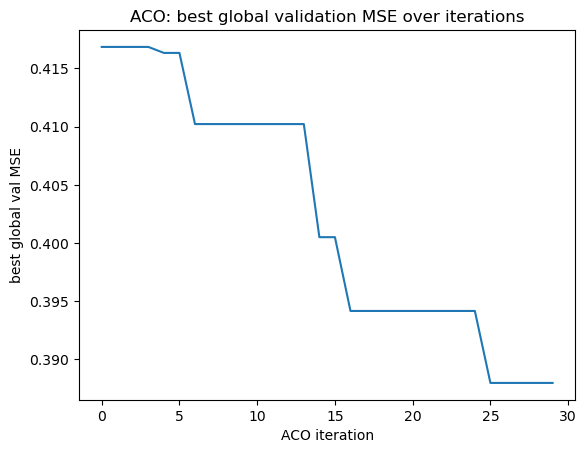

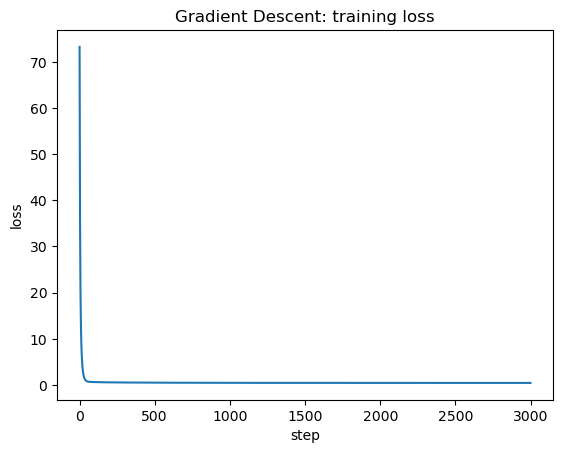

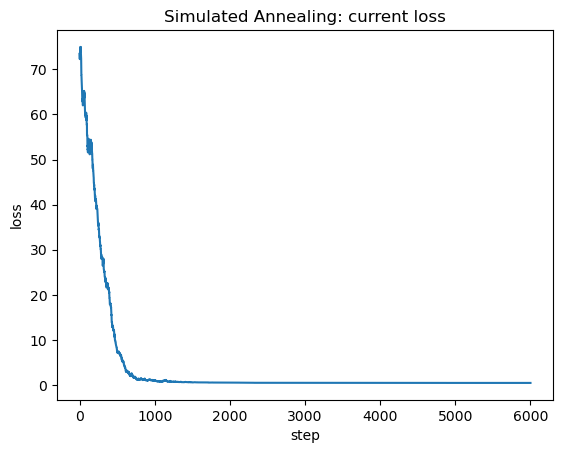

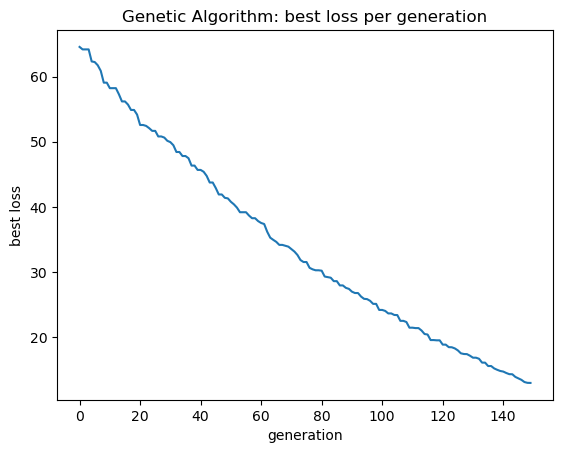

In [28]:
# Cell 14 — Plots: ACO progress + optimizer convergence

# ACO trace
plt.figure()
plt.plot(aco_out["trace"]["best_global_mse"].to_numpy())
plt.title("ACO: best global validation MSE over iterations")
plt.xlabel("ACO iteration")
plt.ylabel("best global val MSE")
plt.show()

# GD convergence
plt.figure()
plt.plot(hist_gd)
plt.title("Gradient Descent: training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

# SA convergence
plt.figure()
plt.plot(hist_sa)
plt.title("Simulated Annealing: current loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

# GA convergence
plt.figure()
plt.plot(hist_ga)
plt.title("Genetic Algorithm: best loss per generation")
plt.xlabel("generation")
plt.ylabel("best loss")
plt.show()

In [29]:
# Cell 15 — Optional: quick robustness check (repeat ONLY the final optimizers on the fixed best subset)

def run_optimizers_on_subset(seed: int) -> Dict:
    Xtr = X_train[:, best_idx]
    Xte = X_test[:, best_idx]

    w_gd, _ = fit_gd(Xtr, y_train, GDConfig(lr=0.05, steps=2500, l2=0.0))
    rmse_gd = rmse(y_test, add_bias(Xte) @ w_gd)

    w_sa, _ = fit_sa(Xtr, y_train, SAConfig(steps=4000, T0=1.0, alpha=0.997, step_sigma=0.05, seed=seed))
    rmse_sa = rmse(y_test, add_bias(Xte) @ w_sa)

    w_ga, _ = fit_ga(Xtr, y_train, GAConfig(pop_size=60, generations=120, seed=seed))
    rmse_ga = rmse(y_test, add_bias(Xte) @ w_ga)

    return {"seed": seed, "rmse_gd": rmse_gd, "rmse_sa": rmse_sa, "rmse_ga": rmse_ga}

seeds = [1, 2, 3, 4, 5]
rob = pd.DataFrame([run_optimizers_on_subset(s) for s in seeds])
rob

,seed,rmse_gd,rmse_sa,rmse_ga
0,1,0.668005,0.692680,4.431854
1,2,0.668005,0.656621,4.298204
2,3,0.668005,0.692211,4.426159
3,4,0.668005,0.656194,4.833415
4,5,0.668005,0.694403,4.513648


In [30]:
# Cell 16 — Optional: robustness INCLUDING ACO (slower)
# This re-runs ACO per seed, then compares optimizers on the resulting subset.

def run_full_pipeline(seed: int) -> Dict:
    gd_cfg_inner = GDConfig(lr=0.05, steps=1000, l2=0.0)

    aco_cfg = ACOConfig(
        n_ants=30,
        n_iters=15,
        evaporation=0.2,
        q=1.0,
        top_k=8,
        subset_min=2,
        subset_max=min(12, len(CANDIDATE_FEATURES)),
        seed=seed
    )

    out = aco_feature_selection(X_train, y_train, X_val, y_val, CANDIDATE_FEATURES, aco_cfg, gd_cfg_inner)
    subset = out["best"]["features"]
    idx = np.array([CANDIDATE_FEATURES.index(f) for f in subset], dtype=int)

    Xtr = X_train[:, idx]
    Xte = X_test[:, idx]

    w_gd, _ = fit_gd(Xtr, y_train, GDConfig(lr=0.05, steps=2500, l2=0.0))
    rmse_gd = rmse(y_test, add_bias(Xte) @ w_gd)

    w_sa, _ = fit_sa(Xtr, y_train, SAConfig(steps=4000, T0=1.0, alpha=0.997, step_sigma=0.05, seed=seed))
    rmse_sa = rmse(y_test, add_bias(Xte) @ w_sa)

    w_ga, _ = fit_ga(Xtr, y_train, GAConfig(pop_size=60, generations=120, seed=seed))
    rmse_ga = rmse(y_test, add_bias(Xte) @ w_ga)

    return {
        "seed": seed,
        "subset_size": len(subset),
        "subset": ",".join(subset),
        "rmse_gd": rmse_gd,
        "rmse_sa": rmse_sa,
        "rmse_ga": rmse_ga
    }

seeds = [1, 2, 3]
full_rob = pd.DataFrame([run_full_pipeline(s) for s in seeds])
full_rob

,seed,subset_size,subset,rmse_gd,rmse_sa,rmse_ga
0,1,12,"doy_cos,water_balance_d,soil_temp_5cm_mean_d,t...",0.604145,0.605573,4.828634
1,2,11,"vapor_pressure_d,year,temp2m_min_d,water_balan...",0.604323,0.582980,4.181937
2,3,12,"temp2m_min_d,temp5cm_mean_d,temp2m_mean_d,heat...",0.588874,0.624627,4.212249
